# Smartticket#

In [53]:
from google.colab import files
files.upload()

{}

In [54]:
import pandas as pd

df = pd.read_csv("SmartTicket_Support_Tickets.csv")

print("File loaded successfully!")

File loaded successfully!


In [55]:
df["Created_Time"] = pd.to_datetime(df["Created_Time"])
df["Resolved_Time"] = pd.to_datetime(df["Resolved_Time"])

In [56]:
df["Resolution_Time_Hours"] = (
    df["Resolved_Time"] - df["Created_Time"]
).dt.total_seconds() / 3600

In [57]:
df["SLA_Status"] = df.apply(
    lambda row: "Breached"
    if row["Resolution_Time_Hours"] > row["SLA_Target_Hours"]
    else "Met"
    if pd.notna(row["Resolution_Time_Hours"])
    else "Open",
    axis=1
)

In [58]:
breached_tickets = df[df["SLA_Status"] == "Breached"]

breached_tickets.head(10)

,Ticket_ID,Category,Issue_Type,Priority,Created_Time,Resolved_Time,Status,Assigned_Agent,SLA_Target_Hours,Resolution_Time_Hours,SLA_Status
5,INC-1006,Email,Mailbox,Medium,2026-09-02 18:14:00,2026-09-03 12:33:00,Closed,Priya,8,18.316667,Breached
7,INC-1008,Email,Mailbox,Medium,2026-09-08 10:29:00,2026-09-09 02:18:00,Resolved,Sneha,8,15.816667,Breached
11,INC-1012,Email,Spam/Phishing,High,2026-09-02 09:09:00,2026-09-02 15:47:00,Closed,Priya,4,6.633333,Breached
16,INC-1017,Hardware,Monitor,High,2026-09-19 09:05:00,2026-09-19 18:57:00,Closed,Rahul,4,9.866667,Breached
18,INC-1019,Network,VPN,Medium,2026-09-13 18:41:00,2026-09-14 08:19:00,Resolved,Sneha,8,13.633333,Breached
27,INC-1028,Email,Email Access,Medium,2026-09-02 08:37:00,2026-09-02 23:10:00,Resolved,Arjun,8,14.550000,Breached
30,INC-1031,Network,Wi-Fi,Medium,2026-09-22 18:19:00,2026-09-23 13:34:00,Resolved,Arjun,8,19.250000,Breached
32,INC-1033,Hardware,Keyboard/Mouse,High,2026-09-18 19:19:00,2026-09-19 03:18:00,Closed,Arjun,4,7.983333,Breached
36,INC-1037,Network,Network Slow,Medium,2026-09-14 16:00:00,2026-09-15 08:24:00,Resolved,Rahul,8,16.400000,Breached
43,INC-1044,Hardware,Keyboard/Mouse,Medium,2026-09-13 18:53:00,2026-09-14 04:37:00,Resolved,Vikram,8,9.733333,Breached


In [59]:
total_by_category = df.groupby("Category").size()

In [60]:
breached_by_category = breached_tickets.groupby("Category").size()

In [61]:
breach_analysis = pd.DataFrame({
    "Total_Tickets": total_by_category,
    "Breached_Tickets": breached_by_category
})

breach_analysis["Breach_Rate_Percent"] = (
    breach_analysis["Breached_Tickets"]
    / breach_analysis["Total_Tickets"]
    * 100
)

breach_analysis

,Total_Tickets,Breached_Tickets,Breach_Rate_Percent
Category,,,
Access,47,9,19.148936
Email,61,15,24.590164
Hardware,71,11,15.492958
Network,57,17,29.824561
Software,64,11,17.187500


In [62]:
resolved_tickets = df[df["SLA_Status"] != "Open"]

sla_compliance_rate = (
    (resolved_tickets["SLA_Status"] == "Met").sum()
    / len(resolved_tickets)
    * 100
)

print(f"Overall SLA Compliance Rate: {sla_compliance_rate:.1f}%")

Overall SLA Compliance Rate: 73.3%


In [63]:
sla_summary = df["SLA_Status"].value_counts()

sla_summary

,count
SLA_Status,
Met,173
Open,64
Breached,63


In [64]:
sla_chart_data = sla_summary.reset_index()

sla_chart_data.columns = ["SLA_Status", "Ticket_Count"]

sla_chart_data

,SLA_Status,Ticket_Count
0,Met,173
1,Open,64
2,Breached,63


In [65]:
resolution_by_category = (
    df.groupby("Category")["Resolution_Time_Hours"]
    .mean()
    .sort_values(ascending=False)
)

resolution_by_category

,Resolution_Time_Hours
Category,
Network,10.415957
Software,8.758667
Email,7.608681
Hardware,6.122727
Access,5.548148


In [66]:
highest_breach_category = breach_analysis["Breach_Rate_Percent"].idxmax()
highest_breach_rate = breach_analysis["Breach_Rate_Percent"].max()

highest_resolution_category = resolution_by_category.idxmax()
highest_resolution_time = resolution_by_category.max()

print("SMARTTICKET KEY INSIGHTS")
print("------------------------")
print(
    f"Highest SLA breach rate: {highest_breach_category} "
    f"({highest_breach_rate:.1f}%)"
)
print(
    f"Highest average resolution time: {highest_resolution_category} "
    f"({highest_resolution_time:.1f} hours)"
)

SMARTTICKET KEY INSIGHTS
------------------------
Highest SLA breach rate: Network (29.8%)
Highest average resolution time: Network (10.4 hours)


In [67]:
total_tickets = len(df)
open_tickets = (df["SLA_Status"] == "Open").sum()
breached_tickets = (df["SLA_Status"] == "Breached").sum()
sla_compliance = sla_compliance_rate

print("SMARTTICKET — MANAGEMENT SUMMARY")
print("=" * 40)

print(f"Total tickets: {total_tickets}")
print(f"Open tickets: {open_tickets}")
print(f"SLA breaches: {breached_tickets}")
print(f"SLA compliance: {sla_compliance:.1f}%")

print()
print(
    f"Network tickets have the highest SLA breach rate "
    f"at {highest_breach_rate:.1f}%."
)

print(
    f"Network tickets also have the highest average "
    f"resolution time at {highest_resolution_time:.1f} hours."
)

SMARTTICKET — MANAGEMENT SUMMARY
Total tickets: 300
Open tickets: 64
SLA breaches: 63
SLA compliance: 73.3%

Network tickets have the highest SLA breach rate at 29.8%.
Network tickets also have the highest average resolution time at 10.4 hours.


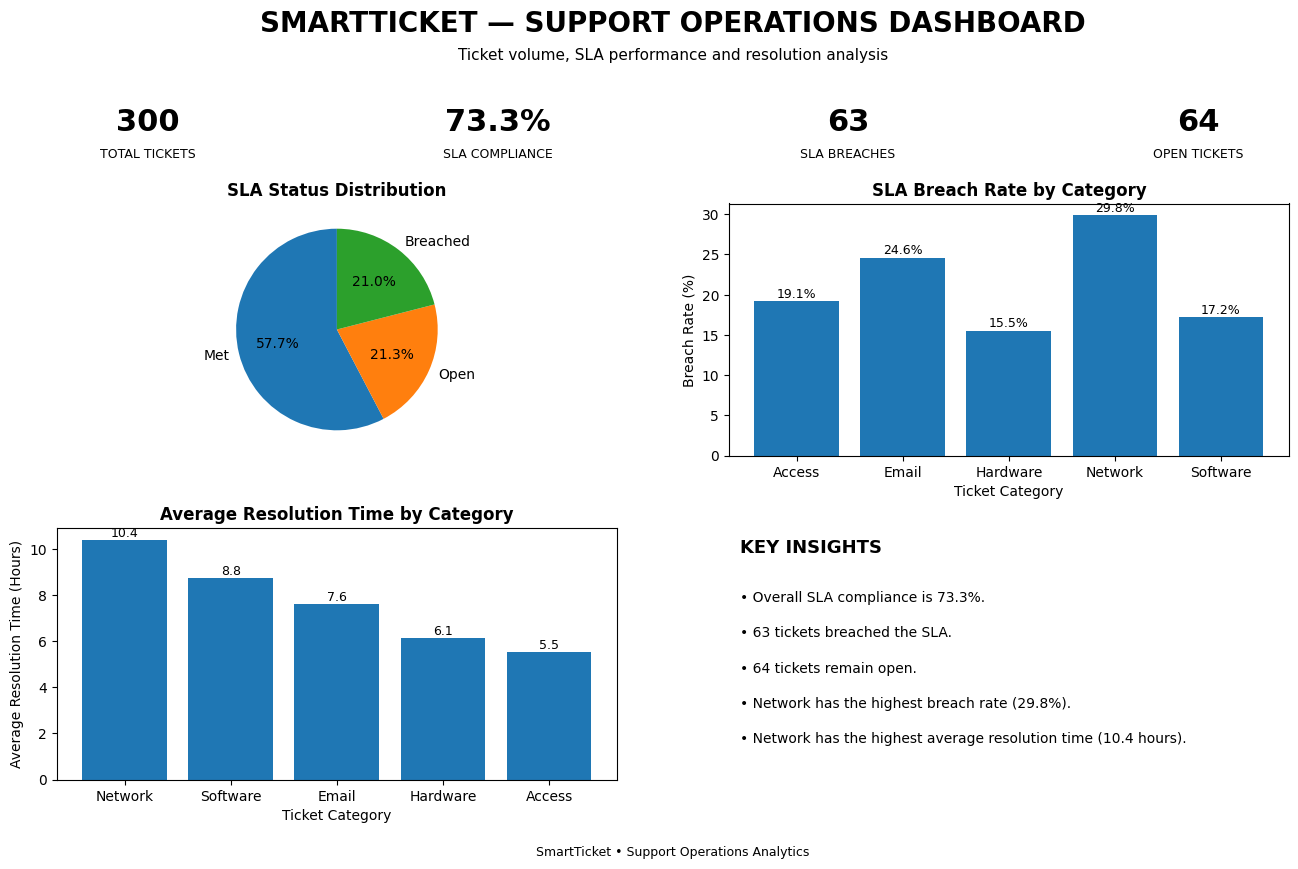

In [68]:
# ============================================================
# SMARTTICKET — FINAL SUPPORT OPERATIONS DASHBOARD
# ============================================================

from IPython.display import clear_output, Image, display
import matplotlib.pyplot as plt

clear_output(wait=True)


# Close any previous figures
plt.close("all")

# Create dashboard
fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor("white")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

fig.text(
    0.5, 0.96,
    "SMARTTICKET — SUPPORT OPERATIONS DASHBOARD",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.5, 0.925,
    "Ticket volume, SLA performance and resolution analysis",
    ha="center",
    va="center",
    fontsize=11
)

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

kpis = [
    ("TOTAL TICKETS", f"{total_tickets}"),
    ("SLA COMPLIANCE", f"{sla_compliance_rate:.1f}%"),
    ("SLA BREACHES", f"{breached_tickets}"),
    ("OPEN TICKETS", f"{open_tickets}")
]

positions = [0.125, 0.375, 0.625, 0.875]

for (label, value), x in zip(kpis, positions):

    fig.text(
        x, 0.85,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    fig.text(
        x, 0.815,
        label,
        ha="center",
        va="center",
        fontsize=9
    )

# ------------------------------------------------------------
# CHART 1 — SLA STATUS
# ------------------------------------------------------------

ax1 = fig.add_axes([0.06, 0.48, 0.40, 0.28])

sla_chart_data = sla_summary.reset_index()
sla_chart_data.columns = ["SLA_Status", "Ticket_Count"]

ax1.pie(
    sla_chart_data["Ticket_Count"],
    labels=sla_chart_data["SLA_Status"],
    autopct="%1.1f%%",
    startangle=90
)

ax1.set_title(
    "SLA Status Distribution",
    fontsize=12,
    fontweight="bold"
)

# ------------------------------------------------------------
# CHART 2 — SLA BREACH RATE
# ------------------------------------------------------------

ax2 = fig.add_axes([0.54, 0.48, 0.40, 0.28])

bars = ax2.bar(
    breach_analysis.index,
    breach_analysis["Breach_Rate_Percent"]
)

ax2.set_title(
    "SLA Breach Rate by Category",
    fontsize=12,
    fontweight="bold"
)

ax2.set_xlabel("Ticket Category")
ax2.set_ylabel("Breach Rate (%)")

ax2.tick_params(axis="x", rotation=0)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        fontsize=9
    )

# ------------------------------------------------------------
# CHART 3 — RESOLUTION TIME
# ------------------------------------------------------------

ax3 = fig.add_axes([0.06, 0.12, 0.40, 0.28])

bars2 = ax3.bar(
    resolution_by_category.index,
    resolution_by_category.values
)

ax3.set_title(
    "Average Resolution Time by Category",
    fontsize=12,
    fontweight="bold"
)

ax3.set_xlabel("Ticket Category")
ax3.set_ylabel("Average Resolution Time (Hours)")

for bar in bars2:
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.1f}",
        ha="center",
        fontsize=9
    )

# ------------------------------------------------------------
# KEY INSIGHTS
# ------------------------------------------------------------

ax4 = fig.add_axes([0.54, 0.12, 0.40, 0.28])
ax4.axis("off")

ax4.text(
    0.02, 0.90,
    "KEY INSIGHTS",
    fontsize=13,
    fontweight="bold"
)

insights = [
    f"• Overall SLA compliance is {sla_compliance_rate:.1f}%.",
    f"• {breached_tickets} tickets breached the SLA.",
    f"• {open_tickets} tickets remain open.",
    f"• {highest_breach_category} has the highest breach rate "
    f"({highest_breach_rate:.1f}%).",
    f"• {highest_resolution_category} has the highest average "
    f"resolution time ({highest_resolution_time:.1f} hours)."
]

y = 0.75

for insight in insights:
    ax4.text(
        0.02, y,
        insight,
        fontsize=10,
        va="top"
    )
    y -= 0.14

# ------------------------------------------------------------
# FOOTER
# ------------------------------------------------------------

fig.text(
    0.5, 0.035,
    "SmartTicket • Support Operations Analytics",
    ha="center",
    fontsize=9
)

# ------------------------------------------------------------
# SAVE + DISPLAY
# -----------------------------------------------------------
output_file = "SmartTicket_Final_Dashboard_v2.png"

fig.savefig(

    output_file,

    dpi=150,

    bbox_inches="tight"

)

plt.show()
